# Part 2: Frozen BERT Embeddings (no fine-tuning)

This part run in an environment with a GPU (Colab with GPU runtime, or a local machine with CUDA).

This notebook picks up **directly from the saved data** produced by the previous notebook:

- `data/train_features_full.csv` — train split, with all previously engineered features
- `data/val_features_full.csv` — val split (leakage-free, grouped by `qid`)
- `data/test_features_full.csv` — held-out test set
- `data/val_predictions.pkl` — validation probabilities from TF-IDF/Word2Vec models (for comparison)
- `data/results_val.csv`, `data/results_train.csv` — metric tables from previous models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import pickle
warnings.filterwarnings('ignore')

import torch
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix, roc_auc_score
import xgboost as xgb

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cpu':
    print('WARNING: no GPU detected! BERT inference on the full dataset will be very slow on CPU.')


Device: cuda


## Load saved data (train/val/test already split, features already engineered)

In [2]:
train_df = pd.read_csv('data/train_features_full.csv')
val_df = pd.read_csv('data/val_features_full.csv')
test_df = pd.read_csv('data/test_features_full.csv')

engineered_features = ['common_word_count', 'union_word_count', 'word_share_jaccard',
                        'common_over_min_len', 'common_over_max_len', 'token_len_diff', 'char_len_diff']
tfidf_sim_cols = ['tfidf_cosine', 'tfidf_euclidean', 'tfidf_manhattan']
w2v_sim_cols = ['w2v_avg_cosine', 'w2v_avg_euclidean', 'w2v_avg_manhattan',
                'w2v_weighted_cosine', 'w2v_weighted_euclidean', 'w2v_weighted_manhattan']

print('Train shape:', train_df.shape)
print('Val shape:  ', val_df.shape)
print('Test shape: ', test_df.shape)

y_train = train_df['is_duplicate'].values
y_val = val_df['is_duplicate'].values
y_test = test_df['is_duplicate'].values


Train shape: (266488, 22)
Val shape:   (56941, 22)
Test shape:  (80858, 22)


In [3]:
# Load previous models' results for the final comparison table
val_results_prev = pd.read_csv('data/results_val.csv')
train_results_prev = pd.read_csv('data/results_train.csv')

with open('data/val_predictions.pkl', 'rb') as f:
    val_predictions = pickle.load(f)

# Sanity check: y_val loaded here must match the one saved earlier from the same split
assert np.array_equal(y_val, val_predictions['y_val']), \
    'y_val mismatch - train/val split differs from the one used to save val_predictions.pkl!'
print('y_val matches the previously saved split - safe to compare models directly.')

val_results_prev


y_val matches the previously saved split - safe to compare models directly.


,model,log_loss,f1,accuracy,roc_auc
0,Наївний baseline (константа),0.672988,0.000000,0.605065,0.500000
1,Поріг на word_share_jaccard,0.650177,0.655511,0.636659,0.722330
2,Logistic Regression (TF-IDF + features),0.525917,0.581317,0.711052,0.804393
3,XGBoost (TF-IDF),0.521324,0.523074,0.699988,0.797677
4,Logistic Regression (Word2Vec),0.531765,0.581234,0.700198,0.790394
5,XGBoost (Word2Vec),0.489078,0.630928,0.737992,0.829651


## Load BERT

**If you get a `gaierror`/`URLError` here** (DNS/network failure while downloading from
`huggingface.co`) — this is the same type of network restriction we hit earlier with `nltk` and
`gensim`. The cell below tries the normal download first, and falls back to a clear manual
instruction if it fails.

In [8]:
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.to(device)
model.eval()  # режим інференсу - вимикає dropout тощо

print('Модель завантажена, hidden_size =', model.config.hidden_size)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель завантажена, hidden_size = 768


## Mean pooling function

Sentence embedding = mean of token embeddings, weighted by `attention_mask` (so padding tokens
don't affect the result) — generally gives better sentence-level representations than the raw
`[CLS]` vector for similarity tasks.

In [9]:
def mean_pooling(token_embeddings, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    summed = torch.sum(token_embeddings * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


@torch.no_grad()
def get_bert_embeddings(texts, tokenizer, model, device, batch_size=64, max_length=64):
    """Batched BERT embedding extraction with mean pooling.

    Writes directly into a preallocated float32 numpy array - storing one array per DataFrame
    row (object dtype column) is very memory-inefficient at this scale and previously caused an
    out-of-memory crash in an earlier phase of this project.
    """
    n = len(texts)
    hidden_size = model.config.hidden_size
    embeddings = np.zeros((n, hidden_size), dtype=np.float32)

    for start in range(0, n, batch_size):
        batch_texts = texts[start:start + batch_size]
        encoded = tokenizer(
            batch_texts, padding=True, truncation=True,
            max_length=max_length, return_tensors='pt'
        ).to(device)

        output = model(**encoded)
        token_embeddings = output.last_hidden_state
        pooled = mean_pooling(token_embeddings, encoded['attention_mask'])

        embeddings[start:start + len(batch_texts)] = pooled.cpu().numpy()

        if start % (batch_size * 50) == 0:
            print(f'  {start}/{n} processed...')

    return embeddings


## Extract BERT embeddings for train / val / test

We use the **raw question text** (not stemmed) — BERT handles context and word forms itself.
Runtime with a GPU: roughly 15-40 minutes total depending on batch size and GPU load.

In [10]:
%%time
q1_bert_train = get_bert_embeddings(train_df['question1'].tolist(), tokenizer, model, device)
q2_bert_train = get_bert_embeddings(train_df['question2'].tolist(), tokenizer, model, device)


  0/266488 processed...
  3200/266488 processed...
  6400/266488 processed...
  9600/266488 processed...
  12800/266488 processed...
  16000/266488 processed...
  19200/266488 processed...
  22400/266488 processed...
  25600/266488 processed...
  28800/266488 processed...
  32000/266488 processed...
  35200/266488 processed...
  38400/266488 processed...
  41600/266488 processed...
  44800/266488 processed...
  48000/266488 processed...
  51200/266488 processed...
  54400/266488 processed...
  57600/266488 processed...
  60800/266488 processed...
  64000/266488 processed...
  67200/266488 processed...
  70400/266488 processed...
  73600/266488 processed...
  76800/266488 processed...
  80000/266488 processed...
  83200/266488 processed...
  86400/266488 processed...
  89600/266488 processed...
  92800/266488 processed...
  96000/266488 processed...
  99200/266488 processed...
  102400/266488 processed...
  105600/266488 processed...
  108800/266488 processed...
  112000/266488 processe

In [11]:
%%time
q1_bert_val = get_bert_embeddings(val_df['question1'].tolist(), tokenizer, model, device)
q2_bert_val = get_bert_embeddings(val_df['question2'].tolist(), tokenizer, model, device)


  0/56941 processed...
  3200/56941 processed...
  6400/56941 processed...
  9600/56941 processed...
  12800/56941 processed...
  16000/56941 processed...
  19200/56941 processed...
  22400/56941 processed...
  25600/56941 processed...
  28800/56941 processed...
  32000/56941 processed...
  35200/56941 processed...
  38400/56941 processed...
  41600/56941 processed...
  44800/56941 processed...
  48000/56941 processed...
  51200/56941 processed...
  54400/56941 processed...
  0/56941 processed...
  3200/56941 processed...
  6400/56941 processed...
  9600/56941 processed...
  12800/56941 processed...
  16000/56941 processed...
  19200/56941 processed...
  22400/56941 processed...
  25600/56941 processed...
  28800/56941 processed...
  32000/56941 processed...
  35200/56941 processed...
  38400/56941 processed...
  41600/56941 processed...
  44800/56941 processed...
  48000/56941 processed...
  51200/56941 processed...
  54400/56941 processed...
CPU times: user 4min 43s, sys: 636 ms, tot

In [12]:
%%time
q1_bert_test = get_bert_embeddings(test_df['question1'].tolist(), tokenizer, model, device)
q2_bert_test = get_bert_embeddings(test_df['question2'].tolist(), tokenizer, model, device)

# The model is no longer needed - free GPU memory before training the ML models
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()


  0/80858 processed...
  3200/80858 processed...
  6400/80858 processed...
  9600/80858 processed...
  12800/80858 processed...
  16000/80858 processed...
  19200/80858 processed...
  22400/80858 processed...
  25600/80858 processed...
  28800/80858 processed...
  32000/80858 processed...
  35200/80858 processed...
  38400/80858 processed...
  41600/80858 processed...
  44800/80858 processed...
  48000/80858 processed...
  51200/80858 processed...
  54400/80858 processed...
  57600/80858 processed...
  60800/80858 processed...
  64000/80858 processed...
  67200/80858 processed...
  70400/80858 processed...
  73600/80858 processed...
  76800/80858 processed...
  80000/80858 processed...
  0/80858 processed...
  3200/80858 processed...
  6400/80858 processed...
  9600/80858 processed...
  12800/80858 processed...
  16000/80858 processed...
  19200/80858 processed...
  22400/80858 processed...
  25600/80858 processed...
  28800/80858 processed...
  32000/80858 processed...
  35200/80858 p

## BERT similarity features (cosine / euclidean / manhattan)

In [13]:
def compute_dense_similarity(A, B):
    dot = np.sum(A * B, axis=1)
    norm_a = np.linalg.norm(A, axis=1)
    norm_b = np.linalg.norm(B, axis=1)
    denom = norm_a * norm_b
    cosine_sim = np.divide(dot, denom, out=np.zeros_like(dot), where=denom != 0)
    euclidean = np.linalg.norm(A - B, axis=1)
    manhattan = np.sum(np.abs(A - B), axis=1)
    return cosine_sim, euclidean, manhattan

bert_sim_cols = ['bert_cosine', 'bert_euclidean', 'bert_manhattan']

for df, q1_emb, q2_emb in [(train_df, q1_bert_train, q2_bert_train),
                           (val_df, q1_bert_val, q2_bert_val),
                           (test_df, q1_bert_test, q2_bert_test)]:
    cos, eucl, manh = compute_dense_similarity(q1_emb, q2_emb)
    df['bert_cosine'] = cos
    df['bert_euclidean'] = eucl
    df['bert_manhattan'] = manh

print('Correlation with is_duplicate (train):')
train_df[bert_sim_cols + ['is_duplicate']].corr()['is_duplicate']


Correlation with is_duplicate (train):


,is_duplicate
bert_cosine,0.400566
bert_euclidean,-0.384724
bert_manhattan,-0.385116
is_duplicate,1.000000


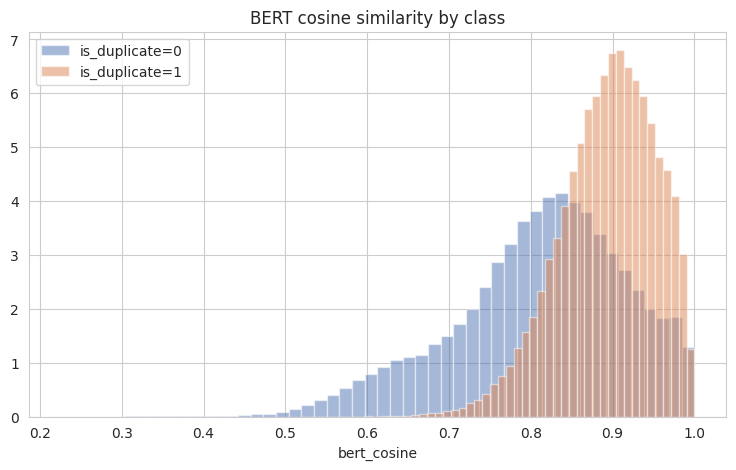

In [14]:
plt.figure(figsize=(9, 5))
for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
    subset = train_df[train_df.is_duplicate == label]
    plt.hist(subset['bert_cosine'], bins=50, alpha=0.5, label=f'is_duplicate={label}', color=color, density=True)
plt.title('BERT cosine similarity by class')
plt.xlabel('bert_cosine')
plt.legend()
plt.show()


## Build the feature matrix: BERT vectors + ALL previously engineered features

Combining BERT embeddings with the engineered/TF-IDF/Word2Vec similarity features already saved
from earlier phases - cheap to include since they're just a handful of extra scalar columns.

In [15]:
all_extra_cols = engineered_features + tfidf_sim_cols + w2v_sim_cols + bert_sim_cols

scaler = StandardScaler()
extra_train_scaled = scaler.fit_transform(train_df[all_extra_cols])
extra_val_scaled = scaler.transform(val_df[all_extra_cols])
extra_test_scaled = scaler.transform(test_df[all_extra_cols])

X_train_bert = np.hstack([q1_bert_train, q2_bert_train, extra_train_scaled])
X_val_bert = np.hstack([q1_bert_val, q2_bert_val, extra_val_scaled])
X_test_bert = np.hstack([q1_bert_test, q2_bert_test, extra_test_scaled])

print('X_train_bert shape:', X_train_bert.shape)
print('X_val_bert shape:  ', X_val_bert.shape)
print('X_test_bert shape: ', X_test_bert.shape)


X_train_bert shape: (266488, 1555)
X_val_bert shape:   (56941, 1555)
X_test_bert shape:  (80858, 1555)


## Model 1: Logistic Regression on BERT features

In [16]:
%%time
logreg_bert = LogisticRegression(max_iter=500, random_state=42)
logreg_bert.fit(X_train_bert, y_train)


CPU times: user 4min 24s, sys: 817 ms, total: 4min 25s
Wall time: 2min 37s


LogisticRegression(max_iter=500, random_state=42)

In [17]:
def add_result(results, model_name, y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    row = {
        'model': model_name,
        'log_loss': log_loss(y_true, y_proba),
        'f1': f1_score(y_true, y_pred),
        'accuracy': accuracy_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }

    results.loc[len(results)] = row
    display(results)

    return results


In [18]:
train_proba_lr_bert = logreg_bert.predict_proba(X_train_bert)[:, 1]
train_preds_lr_bert = (train_proba_lr_bert >= 0.5).astype(int)

val_proba_lr_bert = logreg_bert.predict_proba(X_val_bert)[:, 1]
val_preds_lr_bert = (val_proba_lr_bert >= 0.5).astype(int)


In [19]:
print('='*30+'Train'+'='*30)
train_results = add_result(
    train_results_prev,
    'Logistic Regression (BERT)',
    y_train,
    train_proba_lr_bert
)

print('='*30+'Validation'+'='*30)
val_results = add_result(
    val_results_prev,
    'Logistic Regression (BERT)',
    y_val,
    val_proba_lr_bert
)

==============================Train==============================


,model,log_loss,f1,accuracy,roc_auc
0,Наївний baseline (константа),0.655518,0.000000,0.636299,0.500000
1,Поріг на word_share_jaccard,0.648484,0.632415,0.625364,0.732250
2,Logistic Regression (TF-IDF + features),0.426158,0.697843,0.790347,0.873204
3,XGBoost (TF-IDF),0.448985,0.653174,0.774545,0.858775
4,Logistic Regression (Word2Vec),0.492585,0.623092,0.735035,0.815719
5,XGBoost (Word2Vec),0.360521,0.780661,0.842781,0.922449
6,Logistic Regression (BERT),0.425666,0.705789,0.789011,0.870666


==============================Validation==============================


,model,log_loss,f1,accuracy,roc_auc
0,Наївний baseline (константа),0.672988,0.000000,0.605065,0.500000
1,Поріг на word_share_jaccard,0.650177,0.655511,0.636659,0.722330
2,Logistic Regression (TF-IDF + features),0.525917,0.581317,0.711052,0.804393
3,XGBoost (TF-IDF),0.521324,0.523074,0.699988,0.797677
4,Logistic Regression (Word2Vec),0.531765,0.581234,0.700198,0.790394
5,XGBoost (Word2Vec),0.489078,0.630928,0.737992,0.829651
6,Logistic Regression (BERT),0.502090,0.636392,0.738027,0.826067


## Model 2: XGBoost on BERT features

In [20]:
%%time
xgb_bert = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    tree_method='hist', eval_metric='logloss', random_state=42
)
xgb_bert.fit(X_train_bert, y_train)

CPU times: user 13min 40s, sys: 1.69 s, total: 13min 42s
Wall time: 13min 46s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [21]:
train_proba_xgb_bert = xgb_bert.predict_proba(X_train_bert)[:, 1]
train_preds_xgb_bert = (train_proba_xgb_bert >= 0.5).astype(int)

val_proba_xgb_bert = xgb_bert.predict_proba(X_val_bert)[:, 1]
val_preds_xgb_bert = (val_proba_xgb_bert >= 0.5).astype(int)

In [22]:
print('='*30+'Train'+'='*30)
train_results = add_result(
    train_results_prev,
    'XGBoost (BERT)',
    y_train,
    train_proba_xgb_bert
)

print('='*30+'Validation'+'='*30)
val_results = add_result(
    val_results_prev,
    'XGBoost (BERT)',
    y_val,
    val_proba_xgb_bert
)

==============================Train==============================


,model,log_loss,f1,accuracy,roc_auc
0,Наївний baseline (константа),0.655518,0.000000,0.636299,0.500000
1,Поріг на word_share_jaccard,0.648484,0.632415,0.625364,0.732250
2,Logistic Regression (TF-IDF + features),0.426158,0.697843,0.790347,0.873204
3,XGBoost (TF-IDF),0.448985,0.653174,0.774545,0.858775
4,Logistic Regression (Word2Vec),0.492585,0.623092,0.735035,0.815719
5,XGBoost (Word2Vec),0.360521,0.780661,0.842781,0.922449
6,Logistic Regression (BERT),0.425666,0.705789,0.789011,0.870666
7,XGBoost (BERT),0.325103,0.808335,0.860969,0.938558


==============================Validation==============================


,model,log_loss,f1,accuracy,roc_auc
0,Наївний baseline (константа),0.672988,0.000000,0.605065,0.500000
1,Поріг на word_share_jaccard,0.650177,0.655511,0.636659,0.722330
2,Logistic Regression (TF-IDF + features),0.525917,0.581317,0.711052,0.804393
3,XGBoost (TF-IDF),0.521324,0.523074,0.699988,0.797677
4,Logistic Regression (Word2Vec),0.531765,0.581234,0.700198,0.790394
5,XGBoost (Word2Vec),0.489078,0.630928,0.737992,0.829651
6,Logistic Regression (BERT),0.502090,0.636392,0.738027,0.826067
7,XGBoost (BERT),0.464834,0.669767,0.761806,0.852425


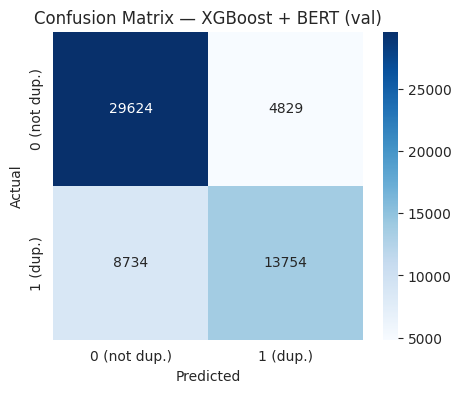

In [23]:
cm_bert = confusion_matrix(y_val, val_preds_xgb_bert)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 (not dup.)', '1 (dup.)'], yticklabels=['0 (not dup.)', '1 (dup.)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — XGBoost + BERT (val)')
plt.show()


## Final test evaluation (best model only) + train/test leakage check

We evaluate only the single best model (by val log loss) on `test.csv` — not every model, to
avoid clutter and to avoid accidentally treating test as the primary comparison metric.

**Important:** we also check the `qid` overlap between the original train/test files. The
original 80/20 split was stratified only by `is_duplicate`, not grouped by question — so some
test questions were already seen (paired differently) during training. This makes test metrics
optimistically biased; val remains the more trustworthy estimate.

In [26]:
best_row = val_results.loc[val_results['log_loss'].idxmin()]
print(f"Best model by val log loss: {best_row['model']} (log_loss={best_row['log_loss']:.4f})")

# Map model name -> (proba_fn, X_test) for the models trained in this notebook.
# If the best model is BERT-based, evaluate it here; otherwise reuse val_predictions
# probabilities is not enough for test (those were only saved for val) - retrain/evaluate
# the relevant model on X_test as needed.
if 'BERT' in best_row['model']:
    best_model_obj = xgb_bert if 'XGBoost' in best_row['model'] else logreg_bert
    test_proba = best_model_obj.predict_proba(X_test_bert)[:, 1]
else:
    print('Best model is not BERT-based - evaluate it on test using its own X_test matrix '
          'from the previous notebook (X_test_tfidf / X_test_w2v).')
    test_proba = None

if test_proba is not None:
    test_preds = (test_proba >= 0.5).astype(int)
    print(f'Test log loss: {log_loss(y_test, test_proba):.4f}')
    print(f'Test F1: {f1_score(y_test, test_preds):.4f}')
    print(f'Test accuracy: {accuracy_score(y_test, test_preds):.4f}')
    print(f'Test ROC-AUC: {roc_auc_score(y_test, test_proba):.4f}')


Best model by val log loss: XGBoost (BERT) (log_loss=0.4648)
Test log loss: 0.3904
Test F1: 0.7383
Test accuracy: 0.8107
Test ROC-AUC: 0.8947


The final evaluation on the test set confirms that the model generalizes well to previously unseen data. XGBoost trained on frozen BERT embeddings achieved the best overall performance, obtaining the lowest log loss and the highest F1 score, accuracy, and ROC-AUC among all evaluated approaches.

These results demonstrate that contextual BERT embeddings provide more informative semantic representations than TF-IDF and Word2Vec features, while the XGBoost classifier effectively exploits these representations. Overall, the proposed approach offers the best trade-off between predictive performance and computational efficiency, as it benefits from pretrained contextual embeddings without requiring expensive BERT fine-tuning.